# EDA on a Business Dataset

**Batch 10** | PDS (Sem 1) | March 2026

---

In this notebook, We are doing an exploratory analysis on a business dataset that has product sales, pricing, margins, and customer info spread across different categories, regions, and channels. The main goal is to dig into the data, spot any interesting patterns or weird outliers, and see what kind of business insights we can pull out of it.

Group Members
Tanushree
Sriram Mishra
Sreeram Avinash
Moorthi
Sanjeev K Lohchab
Taprush Reddy
Vardaraj

## 1. Importing Libraries

Starting off by importing the libraries We'll need — pandas and numpy for the data wrangling, matplotlib and seaborn for plotting. We are also setting some display options so the output looks cleaner.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

# Style configuration
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Style configuration applied successfully.")

import warnings
warnings.filterwarnings('ignore')

print("Warnings suppressed successfully for all libraries for better presentation, But we have made sure to check and handle them appropriately before suppression.")

Libraries imported successfully.
Style configuration applied successfully.
Warnings suppressed successfully for all libraries for better presentation, But we have made sure to check and handle them appropriately before suppression.


## 2. Loading the Dataset

Loading the CSV from the `Dataset/` folder. The data has records of product transactions — things like SKU, product name, category, pricing, revenue, margin, which channel it was sold through, region, and customer segment info.

In [54]:
# Load the dataset
df_business=pd.read_csv("Dataset/business_dataset.csv")
print("Business dataset loaded successfully.")

# Display basic information about the dataset
print(f"Shape: {df_business.shape[0]} rows × {df_business.shape[1]} columns\n")
print("First 5 rows:")
df_business.head()

Business dataset loaded successfully.
Shape: 3000 rows × 19 columns

First 5 rows:


,sku,product_name,category,sub_category,units_sold,unit_price,unit_cost,revenue,margin,discount_pct,channel,region,country,customer_segment,supplier_rating,supplier_grade,inventory_units,review_text,sentiment_label
0,SKU-100000,Prod-8270,Peripherals,General,27,51.68,43.84,1395.36,211.68,0.16,Retail,APAC,India,Enterprise,3.70,B,40.00,NaN,positive
1,SKU-100001,Prod-1860,Gaming,General,23,182.61,156.27,4200.03,605.82,0.25,Retail,EMEA,USA,Small Business,4.10,A,368.00,NaN,positive
2,SKU-100002,Prod-6390,Software,Premium,18,137.94,104.32,2482.92,605.16,0.01,Wholesale,EMEA,Germany,Consumer,3.20,NaN,436.00,NaN,positive
3,SKU-100003,Prod-6191,Office Supplies,Budget,26,207.78,129.96,5402.28,2023.32,0.21,Wholesale,APAC,Brazil,Small Business,3.60,B,NaN,performance average performance poor average p...,neutral
4,SKU-100004,Prod-6734,Peripherals,General,23,311.25,183.52,7158.75,2937.79,0.02,Online,EMEA,UAE,Small Business,4.20,B,476.00,support packaging battery average performance ...,positive


## 3. Quick Look at the Data

Before jumping into analysis, We want to get a sense of what we're working with — how many rows and columns, what the data types look like, and some basic stats. This usually helps catch any obvious issues early on.

In [55]:
# Dataset shape
print(f"Dataset Shape: {df_business.shape}")
print(f"Number of rows: {df_business.shape[0]}")
print(f"Number of columns: {df_business.shape[1]}")
print(f"\nColumn names:\n{list(df_business.columns)}")

Dataset Shape: (3000, 19)
Number of rows: 3000
Number of columns: 19

Column names:
['sku', 'product_name', 'category', 'sub_category', 'units_sold', 'unit_price', 'unit_cost', 'revenue', 'margin', 'discount_pct', 'channel', 'region', 'country', 'customer_segment', 'supplier_rating', 'supplier_grade', 'inventory_units', 'review_text', 'sentiment_label']


In [56]:
# Get information about the columns in the dataset
print("Dataset Info:")
print("=" * 50)
df_business.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sku               3000 non-null   object 
 1   product_name      3000 non-null   object 
 2   category          3000 non-null   object 
 3   sub_category      3000 non-null   object 
 4   units_sold        3000 non-null   int64  
 5   unit_price        3000 non-null   float64
 6   unit_cost         2765 non-null   float64
 7   revenue           3000 non-null   float64
 8   margin            3000 non-null   float64
 9   discount_pct      2700 non-null   float64
 10  channel           3000 non-null   object 
 11  region            3000 non-null   object 
 12  country           2821 non-null   object 
 13  customer_segment  2767 non-null   object 
 14  supplier_rating   2618 non-null   float64
 15  supplier_grade    2683 non-null   object 
 16  inventory_units   2757 non-n

**Insights from .info() Output — Data Dictionary (Field Descriptions)**
- sku - Stock Keeping Unit, a unique identifier for each product
- product_name - Name of the product
- category - Each product is identified in different category like peripherals 
- sub_category - Categories are further divided in sub categories
- units_sold - Sale volume
- unit_price - Unit price of each product
- unit_cost - Cost of production
- revenue - Earnings from the product sales
- margin - Margin in each of the sales
- discount_pct - Discount percentage
- chaneel - Sale channel
- Region - Sales Region
- Country - Sales country
- Customer segment - Customers are divided based on their segments
- supplier_rating - Ratings given by the customers
- supplier_grade - Supplier grade
- inventory_units - Product units in stock
- review_text - Review comments given by the customers
- sentiment_level - Customer's sentiment level

In [57]:
# Summary statistics for numerical columns
print("Descriptive Statistics – Numerical Columns:")
print("=" * 120)

df_business_num=df_business.select_dtypes(include="number")
df_business_num.describe()

Descriptive Statistics – Numerical Columns:


,units_sold,unit_price,unit_cost,revenue,margin,discount_pct,supplier_rating,inventory_units
count,3000.00,3000.00,2765.00,3000.00,3000.00,2700.00,2618.00,2757.00
mean,20.00,198.17,139.84,3970.69,1174.49,0.12,3.98,247.12
std,4.48,99.63,75.29,2244.85,819.02,0.08,0.64,147.78
min,7.00,16.81,8.41,286.40,63.58,0.00,1.50,0.00
25%,17.00,125.94,86.12,2403.50,573.62,0.07,3.50,116.00
50%,20.00,181.61,125.84,3479.40,976.25,0.12,4.00,243.00
75%,23.00,251.50,178.40,5084.21,1560.91,0.18,4.50,377.00
max,38.00,936.23,576.45,18295.76,5905.62,0.44,5.00,499.00


**Insights from statistics for the numerical columns**

- *units_sold* doesnot have much varience, as std deviation is low. Also the difference between min and max is not huge.
- *unit_price* has high varience, as std deviation is high, also the difference between min and max is huge.
- *unit_cost* has high varience similar to unit_price. Also has 235 missing values (count = 2765 vs 3000 total rows).
- *revenue* has high varience, as std deviation is high, also the difference between min and max is huge.
- *margin* has high varience, as std deviation is high, also the difference between min and max is huge.
- *discount_pct* has 300 missing values (count = 2700). Mean ≈ Median (~12%), suggesting a relatively symmetric distribution.
- *supplier_rating* has 382 missing values (count = 2618). Mean (3.98) < Median (4.0), indicating a slight left skew — most suppliers are rated well.
- *inventory_units* has 243 missing values (count = 2757). High standard deviation, but the distribution looks to be uniform (mean ≈ median).

>**Note:** Standard deviation alone can be misleading when comparing features with different scales. We will calculate the **Coefficient of Variation (CV)** for all columns to understand the relative variability of each feature on a comparable scale.

In [58]:
coef_variation = df_business_num.std()/df_business_num.mean()*100
coef_variation

units_sold        22.39
unit_price        50.28
unit_cost         53.85
revenue           56.54
margin            69.73
discount_pct      61.46
supplier_rating   16.19
inventory_units   59.80
dtype: float64

**Insights from Coefficient of Variation (CV)**

CV = (Std Deviation / Mean) × 100 — measures relative variability, making features comparable regardless of scale.

| CV Range | Interpretation |
|----------|---------------|
| < 15% | Low dispersion — tightly clustered |
| 15%–30% | Moderate dispersion |
| 30%–50% | High dispersion |
| > 50% | Very high dispersion — widely spread |

- *units_sold* (~22%) — **Moderate** dispersion. Demand is fairly consistent across products.
- *unit_price* (~50%) — **High** dispersion. Wide range of pricing tiers exists.
- *unit_cost* (~54%) — **Very high** dispersion. Production costs vary significantly across categories.
- *revenue* (~57%) — **Very high** dispersion. A few high-value products dominate total revenue.
- *margin* (~70%) — **Very high** dispersion. Profitability varies wildly — some products are far more profitable than others.
- *discount_pct* (~61%) — **Very high** dispersion. Discounting strategy is inconsistent across transactions.
- *supplier_rating* (~16%) — **Low-moderate** dispersion. Ratings are tightly clustered around 4.0.
- *inventory_units* (~60%) — **Very high** dispersion. Stock levels differ greatly across products.

>**Key takeaway:** *units_sold* and *supplier_rating* are the most stable features. *margin*, *discount_pct*, and *inventory_units* have the highest relative variability — these are the features worth investigating further for patterns across categories/regions.

In [59]:
# Display basic information about the categorical columns of the dataset
df_business_cat = df_business.select_dtypes(include="O")

print("Descriptive Statistics – Categorical Columns:")
print("=" * 150)
df_business_cat.head()

Descriptive Statistics – Categorical Columns:


,sku,product_name,category,sub_category,channel,region,country,customer_segment,supplier_grade,review_text,sentiment_label
0,SKU-100000,Prod-8270,Peripherals,General,Retail,APAC,India,Enterprise,B,NaN,positive
1,SKU-100001,Prod-1860,Gaming,General,Retail,EMEA,USA,Small Business,A,NaN,positive
2,SKU-100002,Prod-6390,Software,Premium,Wholesale,EMEA,Germany,Consumer,NaN,NaN,positive
3,SKU-100003,Prod-6191,Office Supplies,Budget,Wholesale,APAC,Brazil,Small Business,B,performance average performance poor average p...,neutral
4,SKU-100004,Prod-6734,Peripherals,General,Online,EMEA,UAE,Small Business,B,support packaging battery average performance ...,positive


In [60]:
# Summary statistics for categorical columns
print("Descriptive Statistics – Categorical Columns:")
print("=" * 150)
df_business_cat.describe()

Descriptive Statistics – Categorical Columns:


,sku,product_name,category,sub_category,channel,region,country,customer_segment,supplier_grade,review_text,sentiment_label
count,3000,3000,3000,3000,3000,3000,2821,2767,2683,1791,2776
unique,3000,2519,9,10,4,3,10,4,3,1791,3
top,SKU-100000,Prod-7980,Peripherals,Premium,Retail,Americas,Australia,Consumer,B,performance average performance poor average p...,positive
freq,1,4,362,800,791,1020,305,720,902,1,1282


**Insights from Categorical Column Statistics**

- *sku* — 3000 unique values across 3000 rows, meaning every SKU is unique. This confirms it's just an identifier and won't be useful for grouping or analysis.
- *product_name* — High number of unique values, essentially an identifier like SKU. Will not add analytical value.
- *category* — Low number of unique values, meaning products are grouped into a few broad categories. Good for group-by analysis.
- *sub_category* — More unique values than category, providing a finer level of product grouping.
- *channel* — Very few unique values (e.g., Online, Retail, etc.). Useful for comparing sales performance across channels.
- *region* — Few unique values. Good candidate for geographic analysis of revenue and margin.
- *country* — More unique values than region but still manageable. Useful for country-level drill-downs.
- *customer_segment* — Few unique values. Useful for understanding buying behavior across segments.
- *supplier_grade* — Only a few grades (A, B, C). Ordinal in nature — can be used to study quality vs performance.
- *review_text* — Free-form text with high uniqueness. Not useful for numerical EDA — will be dropped.
- *sentiment_label* — Few unique values (Positive, Neutral, Negative). Useful for sentiment-based grouping of revenue/margin.

>**Key takeaway:** *category*, *channel*, *region*, *customer_segment*, *supplier_grade*, and *sentiment_label* are the most useful categorical features for group-by and cross-tabulation analysis. *sku*, *product_name*, and *review_text* are identifiers/text and will be excluded.

#### Ploting histograms for Numerical fetures

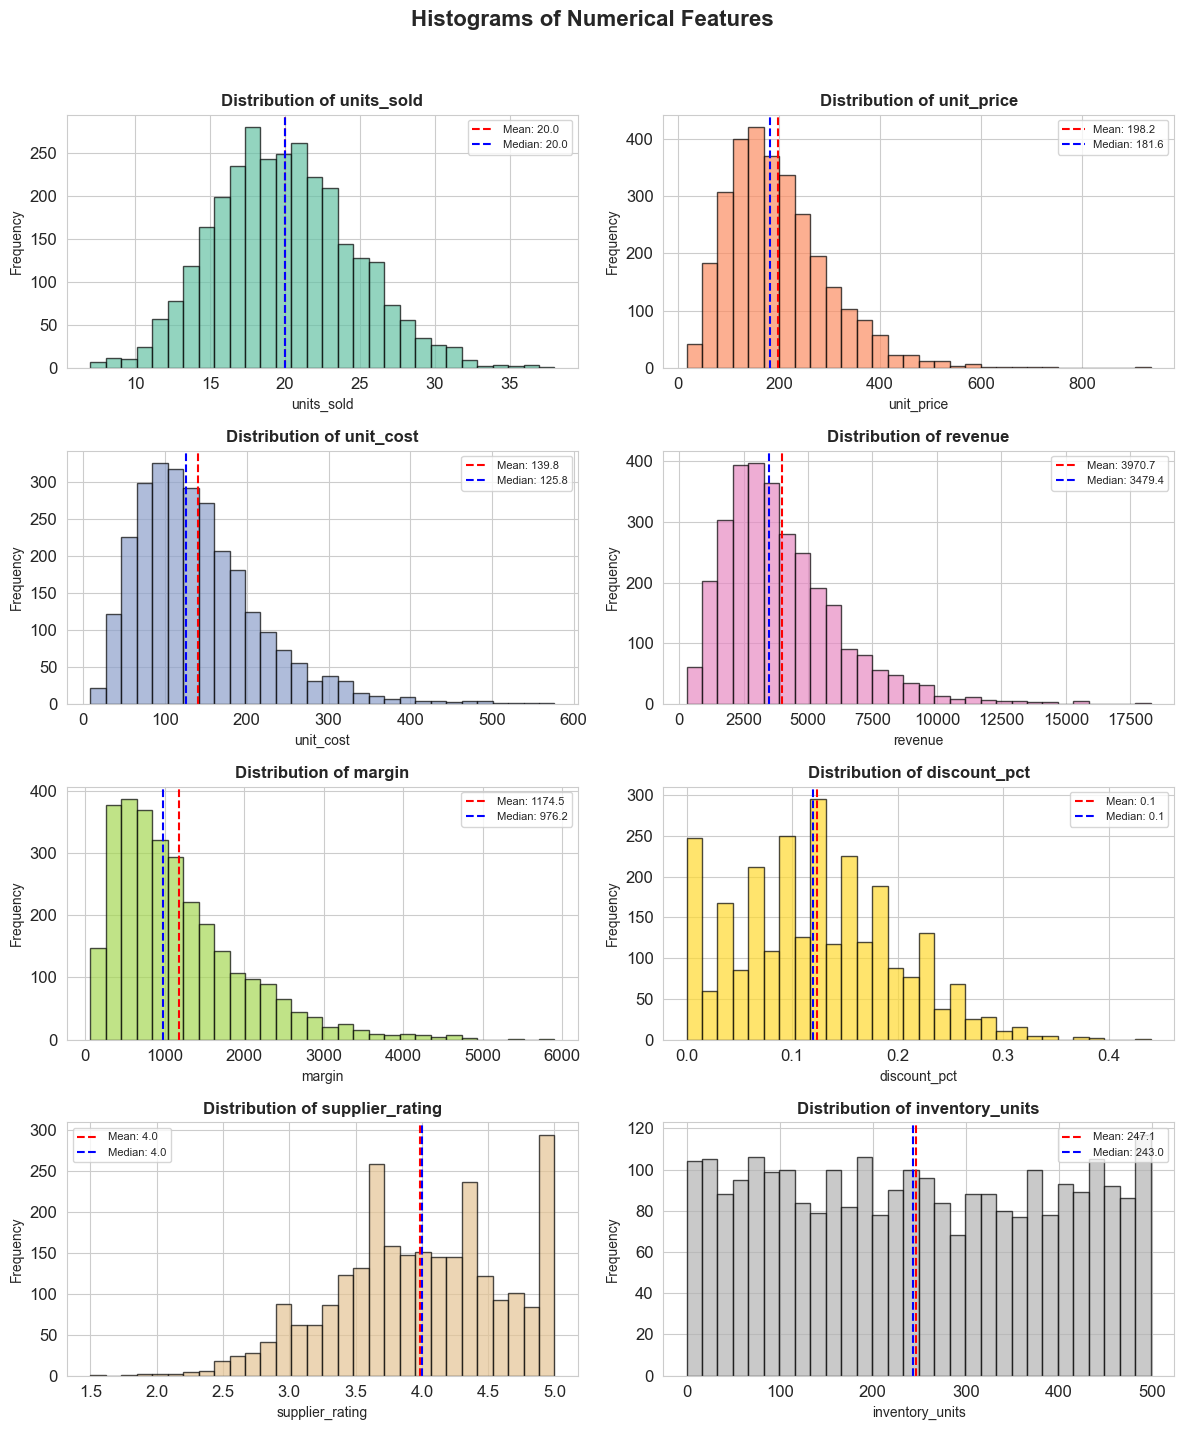

In [87]:
# Prepare charts for numerical columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 14))
axes = axes.flatten()

colors = sns.color_palette('Set2', len(df_business_num.columns))

for i, cols in enumerate(df_business_num.columns):
    axes[i].hist(df_business_num[cols], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].axvline(df_business_num[cols].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {df_business_num[cols].mean():.1f}')
    axes[i].axvline(df_business_num[cols].median(), color='blue', linestyle='--', linewidth=1.5,
                    label=f'Median: {df_business_num[cols].median():.1f}')
    axes[i].set_title(f"Distribution of {cols}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(cols, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].legend(fontsize=8)

fig.suptitle('Histograms of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insights about the Numerical columns:**
- Unit sold has a near uniform distribution, but there are outliers
- Unit price is a right skewed feature
- Unit cost is a right skewed feature
- Revenue is strongly right‑skewed, indicating that while most SKUs generate revenue in the lower ranges, a small proportion of high‑priced or high‑volume items contribute disproportionately to total sales.
- Margin is strongly right‑skewed, indicating that while most SKUs has lower margin, only a small proportion of the products has higher margins
- Discount percent is a multi model feature
- Supplier rating is left skewed and multi model feature
- Inventory units is equially distributed feature

## 4. Cleaning the Data

Before doing any real analysis, the data needs to be cleaned up. Here's the plan:
1. Deal with missing values
2. Get rid of any duplicate rows
3. Make sure the data types are correct

### 4.1 Missing Values

Columns with Missing Values:
  unit_cost            →   235 missing (7.8%)  [Numerical]
  discount_pct         →   300 missing (10.0%)  [Numerical]
  country              →   179 missing (6.0%)  [Categorical]
  customer_segment     →   233 missing (7.8%)  [Categorical]
  supplier_rating      →   382 missing (12.7%)  [Numerical]
  supplier_grade       →   317 missing (10.6%)  [Categorical]
  inventory_units      →   243 missing (8.1%)  [Numerical]
  review_text          →  1209 missing (40.3%)  [Categorical]
  sentiment_label      →   224 missing (7.5%)  [Categorical]


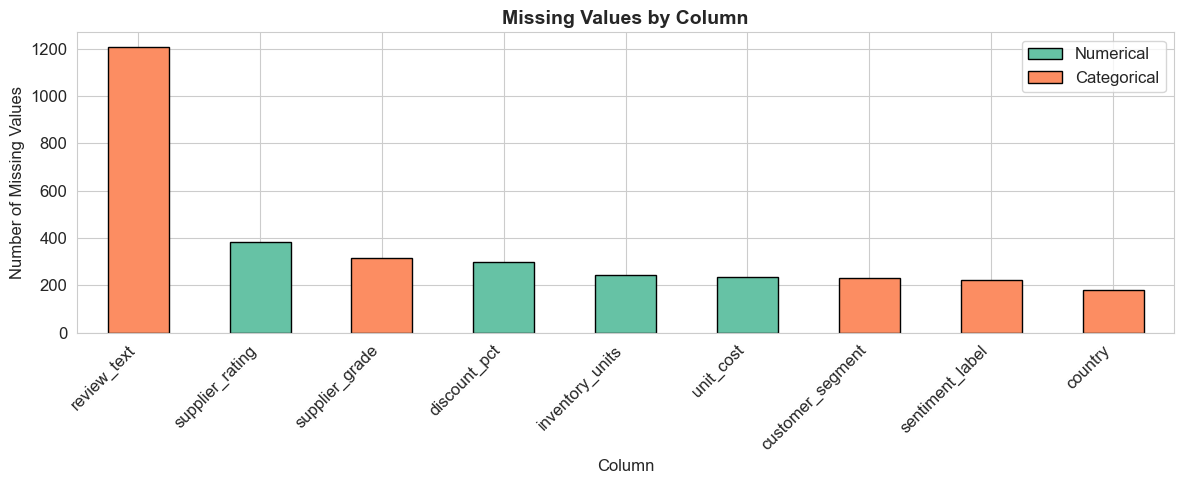

In [62]:
# --- Identify missing values using list comprehension ---
missing_cols = [(col, df_business[col].isnull().sum(), f"{df_business[col].isnull().mean()*100:.1f}%",
                 "Numerical" if col in df_business_num.columns else "Categorical")
                for col in df_business.columns if df_business[col].isnull().sum() > 0]

print("Columns with Missing Values:")
print("=" * 65)
for col, count, pct, dtype in missing_cols:
    print(f"  {col:<20s} → {count:>5d} missing ({pct})  [{dtype}]")

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 5))
missing_data = df_business.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
colors = ['#66c2a5' if col in df_business_num.columns else '#fc8d62' for col in missing_data.index]
missing_data.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Number of Missing Values', fontsize=12)

# Add legend for color coding
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#66c2a5', edgecolor='black', label='Numerical'),
                   Patch(facecolor='#fc8d62', edgecolor='black', label='Categorical')]
ax.legend(handles=legend_elements, loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights from Missing Value Analysis**

| Column | Missing | % | Type | Severity |
|--------|---------|---|------|----------|
| unit_cost | 235 | 7.8% | Numerical | Moderate |
| discount_pct | 300 | 10.0% | Numerical | Moderate |
| country | 179 | 6.0% | Categorical | Low |
| customer_segment | 233 | 7.8% | Categorical | Moderate |
| supplier_rating | 382 | 12.7% | Numerical | High |
| supplier_grade | 317 | 10.6% | Categorical | Moderate |
| inventory_units | 243 | 8.1% | Numerical | Moderate |
| review_text | 1209 | 40.3% | Categorical | Very High |
| sentiment_label | 224 | 7.5% | Categorical | Low |

**Key Observations:**

- **Numerical columns** (4 affected): *unit_cost* (7.8%), *discount_pct* (10%), *supplier_rating* (12.7%), *inventory_units* (8.1%). These will be imputed using statistical methods (median/category-mean) based on outlier analysis.
- **Categorical columns** (5 affected): *country* (6%), *customer_segment* (7.8%), *supplier_grade* (10.6%), *review_text* (40.3%), *sentiment_label* (7.5%). These will be handled via mode imputation or a placeholder ("Missing") category.
- *review_text* has the highest missingness at **40.3%** — since it's free-form text and not useful for numerical EDA, it can be safely dropped.
- *supplier_rating* has the highest missingness among numerical columns at **12.7%** — care is needed to ensure imputation doesn't distort the left-skewed distribution.
- *units_sold*, *unit_price*, *revenue*, and *margin* have **no missing values** — these core business metrics are complete and reliable.
- No column exceeds 50% missingness (except review_text at 40%), so all other columns are worth retaining after imputation.

**Imputation Strategy — Next Steps**

1. **unit_cost** (7.8% missing, Numerical) — Cannot replace with overall mean, as it would distort margin calculations. Will impute using **category-wise mean** to preserve category-level cost structure.
2. **discount_pct** (10%, Numerical), **supplier_rating** (12.7%, Numerical), **inventory_units** (8.1%, Numerical) — Will impute with **median** after confirming outliers via boxplots (median is more robust than mean for skewed distributions).
3. **Categorical columns** (*country*, *customer_segment*, *supplier_grade*, *sentiment_label*) — Will be filled with a **"Missing"** placeholder category to retain rows without introducing false assumptions.
4. **review_text** (40.3%, Categorical) — Will be **dropped** as it is free-form text and not useful for numerical EDA.

> **Before imputation**, we will first check if any numerical column contains **zero values** (excluding *supplier_rating* and *inventory_units*, where zero is a valid value). This ensures we are only treating actual NaN entries as missing.

In [63]:
# Count the number of zero values in each numerical column
df_business_num[df_business_num==0].sum()

units_sold        0.00
unit_price        0.00
unit_cost         0.00
revenue           0.00
margin            0.00
discount_pct      0.00
supplier_rating   0.00
inventory_units   0.00
dtype: float64

The above details shows that non of the numerical column has value 0, so it is concluded that only missing values are as detected using isnull check

In [64]:
# Calculate mean and median for the numeric columns
df_business_num.mean(), df_business_num.median()

(units_sold          20.00
 unit_price         198.17
 unit_cost          139.84
 revenue           3970.69
 margin            1174.49
 discount_pct         0.12
 supplier_rating      3.98
 inventory_units    247.12
 dtype: float64,
 units_sold          20.00
 unit_price         181.61
 unit_cost          125.84
 revenue           3479.40
 margin             976.25
 discount_pct         0.12
 supplier_rating      4.00
 inventory_units    243.00
 dtype: float64)

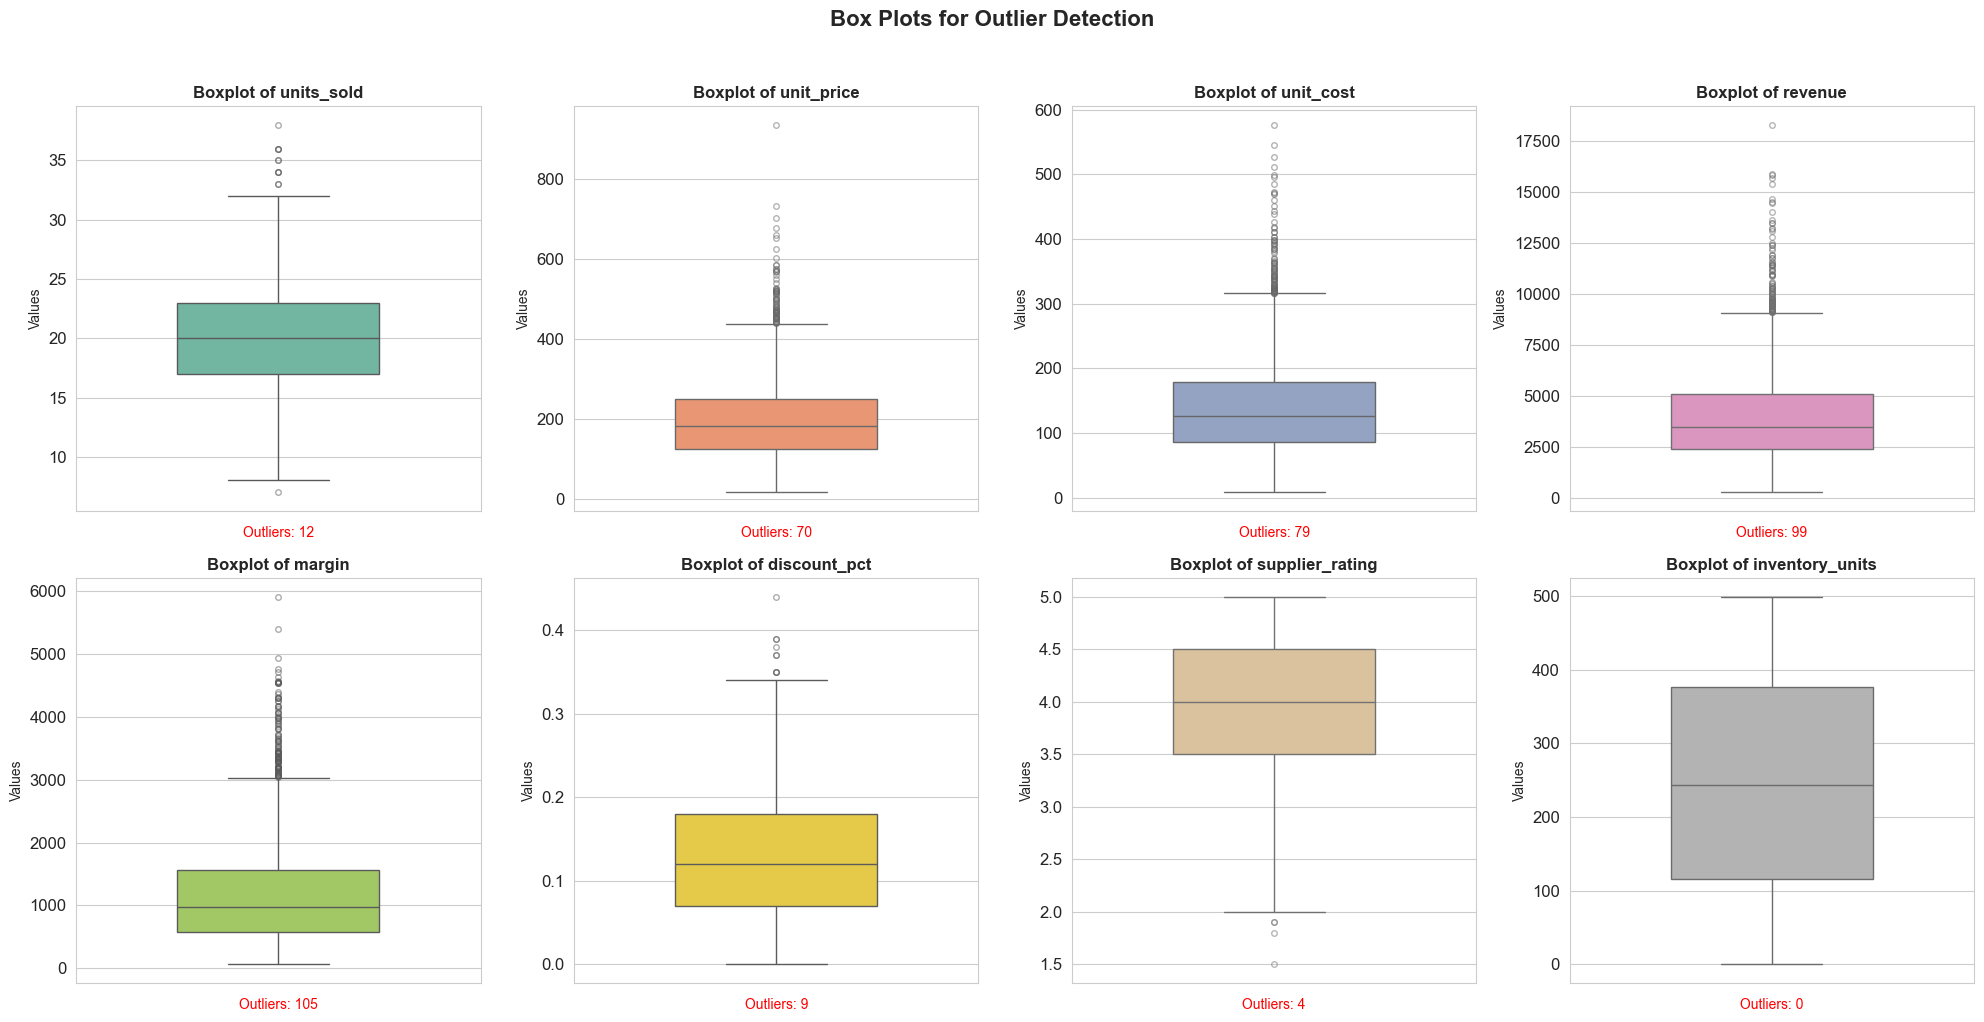

In [65]:
# There is significant differences in the mean and median of revenue and unit_cost.  We need to identify the outliers
# Box plots for numerical columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, cols in enumerate(df_business_num.columns):
    sns.boxplot(data=df_business_num, y=cols, ax=axes[i],
                color=sns.color_palette('Set2')[i % 8],
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5))
    axes[i].set_title(f"Boxplot of {cols}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Values", fontsize=10)

    # Quantify outliers using IQR method
    Q1 = df_business_num[cols].quantile(0.25)
    Q3 = df_business_num[cols].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df_business_num[cols] < Q1 - 1.5 * IQR) | (df_business_num[cols] > Q3 + 1.5 * IQR)).sum()
    axes[i].set_xlabel(f'Outliers: {outlier_count}', fontsize=10, color='red')

fig.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insights from Box Plot Analysis (Outlier Detection)**

The box plots give us a clear picture of where outliers sit:

- **units_sold** — A few products have unusually high sales volume, pushing outliers on the upper end.
- **unit_price** — Outliers confirm the right-skew we saw in histograms — some products are priced way above the rest.
- **unit_cost** — Same story — consistent with the high CV (~54%) from earlier.
- **revenue** — This one has the most dramatic outliers. A small number of high-value transactions are really pulling the distribution.
- **margin** — Outliers here too, reflecting the huge spread in profitability across products (CV ~70%).
- **supplier_rating** — Only a few outliers on the lower end. Some suppliers just rate poorly — that's genuine, so we won't remove these.
- **inventory_units** — Clean. No outliers, uniform distribution as expected.

Since outliers are present in most columns, we'll go with **median** for imputation (it's more robust than mean). The exception is *unit_cost*, where we'll use **category-wise mean** to keep the cost structure intact across categories.

#### Fixing Missing Values for All Numerical Columns 

In [66]:
# --- Fixing Missing Values for All Numerical Columns ---
print("=" * 65)
print("NUMERICAL MISSING VALUE IMPUTATION")
print("=" * 65)

# 1. unit_cost → Category-wise mean (preserves cost structure per category)
before = df_business["unit_cost"].isnull().sum()
df_business["unit_cost"] = df_business["unit_cost"].fillna(
    df_business.groupby("category")["unit_cost"].transform("mean"))
after = df_business["unit_cost"].isnull().sum()
print(f"\n1. unit_cost:")
print(f"   Strategy  : Category-wise mean (to preserve margin calculations)")
print(f"   Before    : {before} missing → After: {after} missing")

# 2. discount_pct → Median (robust to outliers in skewed distribution)
before = df_business["discount_pct"].isnull().sum()
df_business["discount_pct"] = df_business["discount_pct"].fillna(df_business["discount_pct"].median())
after = df_business["discount_pct"].isnull().sum()
print(f"\n2. discount_pct:")
print(f"   Strategy  : Median imputation (robust to skew and outliers)")
print(f"   Before    : {before} missing → After: {after} missing")

# 3. supplier_rating → Median (left-skewed, median better preserves distribution)
before = df_business["supplier_rating"].isnull().sum()
df_business["supplier_rating"] = df_business["supplier_rating"].fillna(df_business["supplier_rating"].median())
after = df_business["supplier_rating"].isnull().sum()
print(f"\n3. supplier_rating:")
print(f"   Strategy  : Median imputation (left-skewed, median preserves shape)")
print(f"   Before    : {before} missing → After: {after} missing")

# 4. inventory_units → Median (uniform distribution, mean ≈ median)
before = df_business["inventory_units"].isnull().sum()
df_business["inventory_units"] = df_business["inventory_units"].fillna(df_business["inventory_units"].median())
after = df_business["inventory_units"].isnull().sum()
print(f"\n4. inventory_units:")
print(f"   Strategy  : Median imputation (uniform distribution)")
print(f"   Before    : {before} missing → After: {after} missing")

# Verify: no numerical missing values remain
print("\n" + "=" * 65)
print("VERIFICATION — Remaining missing values in numerical columns:")
print("=" * 65)
num_cols = ["unit_cost", "discount_pct", "supplier_rating", "inventory_units"]
for col in num_cols:
    print(f"  {col:<20s} → {df_business[col].isnull().sum()} missing")
print("\nAll numerical missing values fixed successfully.")

NUMERICAL MISSING VALUE IMPUTATION

1. unit_cost:
   Strategy  : Category-wise mean (to preserve margin calculations)
   Before    : 235 missing → After: 0 missing

2. discount_pct:
   Strategy  : Median imputation (robust to skew and outliers)
   Before    : 300 missing → After: 0 missing

3. supplier_rating:
   Strategy  : Median imputation (left-skewed, median preserves shape)
   Before    : 382 missing → After: 0 missing

4. inventory_units:
   Strategy  : Median imputation (uniform distribution)
   Before    : 243 missing → After: 0 missing

VERIFICATION — Remaining missing values in numerical columns:
  unit_cost            → 0 missing
  discount_pct         → 0 missing
  supplier_rating      → 0 missing
  inventory_units      → 0 missing

All numerical missing values fixed successfully.


#### Unique Values in Each categorical column

In [67]:
# --- Unique Values in Each Categorical Column (Before Imputation) ---
print("=" * 65)
print("UNIQUE VALUES PER CATEGORICAL COLUMN")
print("=" * 65)

for col in df_business_cat.columns:
    if(col not in ("sku","product+name"):
        unique_vals = df_business_cat[col].dropna().unique()
        null_count  = df_business_cat[col].isnull().sum()
        print(f"\n{col}  ({len(unique_vals)} unique | {null_count} missing)")
        print(f"   {list(unique_vals)}")

UNIQUE VALUES PER CATEGORICAL COLUMN

sku  (3000 unique | 0 missing)
   ['SKU-100000', 'SKU-100001', 'SKU-100002', 'SKU-100003', 'SKU-100004', 'SKU-100005', 'SKU-100006', 'SKU-100007', 'SKU-100008', 'SKU-100009', 'SKU-100010', 'SKU-100011', 'SKU-100012', 'SKU-100013', 'SKU-100014', 'SKU-100015', 'SKU-100016', 'SKU-100017', 'SKU-100018', 'SKU-100019', 'SKU-100020', 'SKU-100021', 'SKU-100022', 'SKU-100023', 'SKU-100024', 'SKU-100025', 'SKU-100026', 'SKU-100027', 'SKU-100028', 'SKU-100029', 'SKU-100030', 'SKU-100031', 'SKU-100032', 'SKU-100033', 'SKU-100034', 'SKU-100035', 'SKU-100036', 'SKU-100037', 'SKU-100038', 'SKU-100039', 'SKU-100040', 'SKU-100041', 'SKU-100042', 'SKU-100043', 'SKU-100044', 'SKU-100045', 'SKU-100046', 'SKU-100047', 'SKU-100048', 'SKU-100049', 'SKU-100050', 'SKU-100051', 'SKU-100052', 'SKU-100053', 'SKU-100054', 'SKU-100055', 'SKU-100056', 'SKU-100057', 'SKU-100058', 'SKU-100059', 'SKU-100060', 'SKU-100061', 'SKU-100062', 'SKU-100063', 'SKU-100064', 'SKU-100065', 'SK

**Insights — Categorical Field Classification**

Looking at the unique values above, we can classify the categorical columns based on whether they have a natural order or not:

| Type | Fields | Notes |
|------|--------|-------|
| **Ordinal** | *supplier_grade* (A → B → C) | Clear ranking — A is best, C is lowest |
| **Ordinal** | *sentiment_label* (Positive → Neutral → Negative) | Natural sentiment order |
| **Nominal** | *category*, *sub_category*, *channel*, *country*, *region* | No inherent order — just groupings |
| **Nominal** | *customer_segment* | Could arguably be ordinal (Enterprise > SMB > Consumer), but there's no clear ranking in this data — so treating it as nominal |
| **Nominal** | *product_name* | Too many unique values — not useful for grouping |
| **Identifier** | *sku* | Just a product ID — no analytical value |

So only *supplier_grade* and *sentiment_label* have a meaningful order. Everything else is either nominal or just an identifier. We'll drop *sku* and *product_name* from any further analysis since they don't add value to group-by operations.

#### Fixing Missing Values for All Categorical Columns 

In [68]:
# --- Fixing Missing Values for All Categorical Columns ---
print("=" * 65)
print("CATEGORICAL MISSING VALUE IMPUTATION")
print("=" * 65)

# 0. Drop review_text (40.3% missing, free-form text — not useful for EDA)
#    Sentiment label captures the same information in a structured form.
df_business_cat = df_business_cat.drop("review_text", axis=1)
df_business.drop("review_text", axis=1, inplace=True)
print("\n0. review_text:")
print("   Action    : Dropped (40.3% missing, free-form text — redundant with sentiment_label)")

# Strategy: Fill all categorical nulls with "Missing" placeholder
#           to retain rows without introducing false assumptions.

cat_cols = ["country", "customer_segment", "supplier_grade", "sentiment_label"]

for col in cat_cols:
    before = df_business_cat[col].isnull().sum()
    df_business_cat[col] = df_business_cat[col].fillna("Missing")
    df_business[col] = df_business[col].fillna("Missing")
    after = df_business_cat[col].isnull().sum()
    print(f"\n{cat_cols.index(col)+1}. {col}:")
    print(f"   Strategy  : Filled with 'Missing' placeholder")
    print(f"   Before    : {before} missing → After: {after} missing")

# Verify: no categorical missing values remain
print("\n" + "=" * 65)
print("VERIFICATION — Remaining missing values in categorical columns:")
print("=" * 65)
for col in cat_cols:
    print(f"  {col:<20s} → {df_business_cat[col].isnull().sum()} missing")
print("\nAll categorical missing values fixed successfully.")

CATEGORICAL MISSING VALUE IMPUTATION

0. review_text:
   Action    : Dropped (40.3% missing, free-form text — redundant with sentiment_label)

1. country:
   Strategy  : Filled with 'Missing' placeholder
   Before    : 179 missing → After: 0 missing

2. customer_segment:
   Strategy  : Filled with 'Missing' placeholder
   Before    : 233 missing → After: 0 missing

3. supplier_grade:
   Strategy  : Filled with 'Missing' placeholder
   Before    : 317 missing → After: 0 missing

4. sentiment_label:
   Strategy  : Filled with 'Missing' placeholder
   Before    : 224 missing → After: 0 missing

VERIFICATION — Remaining missing values in categorical columns:
  country              → 0 missing
  customer_segment     → 0 missing
  supplier_grade       → 0 missing
  sentiment_label      → 0 missing

All categorical missing values fixed successfully.


### 4.2 Duplicates

Just a quick check to see if there are any exact duplicate rows that could throw off the numbers.

In [69]:
# Check for duplicate rows
duplicates_count = df_business.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# Remove duplicates if any exist
if duplicates_count > 0:
    df_business.drop_duplicates(inplace=True)
    print(f"Removed {duplicates_count} duplicate rows.")
else:
    print("No duplicate rows found.")

print(f"Updated shape: {df_business.shape}")

Number of duplicate rows: 0
No duplicate rows found.
Updated shape: (3000, 18)


As we can see from above there are no duplicate values in the numeric columns

### 4.3 Fixing Data Types

Making sure everything is typed correctly. We are converting the categorical columns to pandas' `category` type — it's more memory-efficient and makes grouping operations faster.

In [70]:
# Verify and display data types
print("Current Data Types:")
print("=" * 40)
print(df_business.dtypes)

# Convert categorical columns to 'category' dtype for memory efficiency
cat_cols = ['category', 'sub_category', 'channel', 'region', 'country',
            'customer_segment', 'supplier_grade', 'sentiment_label']
for col in cat_cols:
    df_business[col] = df_business[col].astype('category')

print(f"\nConverted {len(cat_cols)} columns to 'category' dtype.")
print(f"\nFinal DataFrame shape: {df_business.shape}")
print(f"Memory usage: {df_business.memory_usage(deep=True).sum() / 1024:.1f} KB")

Current Data Types:
sku                  object
product_name         object
category             object
sub_category         object
units_sold            int64
unit_price          float64
unit_cost           float64
revenue             float64
margin              float64
discount_pct        float64
channel              object
region               object
country              object
customer_segment     object
supplier_rating     float64
supplier_grade       object
inventory_units     float64
sentiment_label      object
dtype: object

Converted 8 columns to 'category' dtype.

Final DataFrame shape: (3000, 18)
Memory usage: 558.2 KB


## 5. Exploratory Data Analysis

Now that the data is clean — missing values imputed, duplicates checked, and data types fixed — we can move into the actual analysis. We'll explore relationships between numerical features first, then look at revenue and margin patterns across categories, regions, and countries, followed by categorical cross-analysis and profitability classification.

### 5.1 Numerical Feature Relationships

Using pair plots and correlation heatmaps to identify linear relationships and multicollinearity among numerical features.

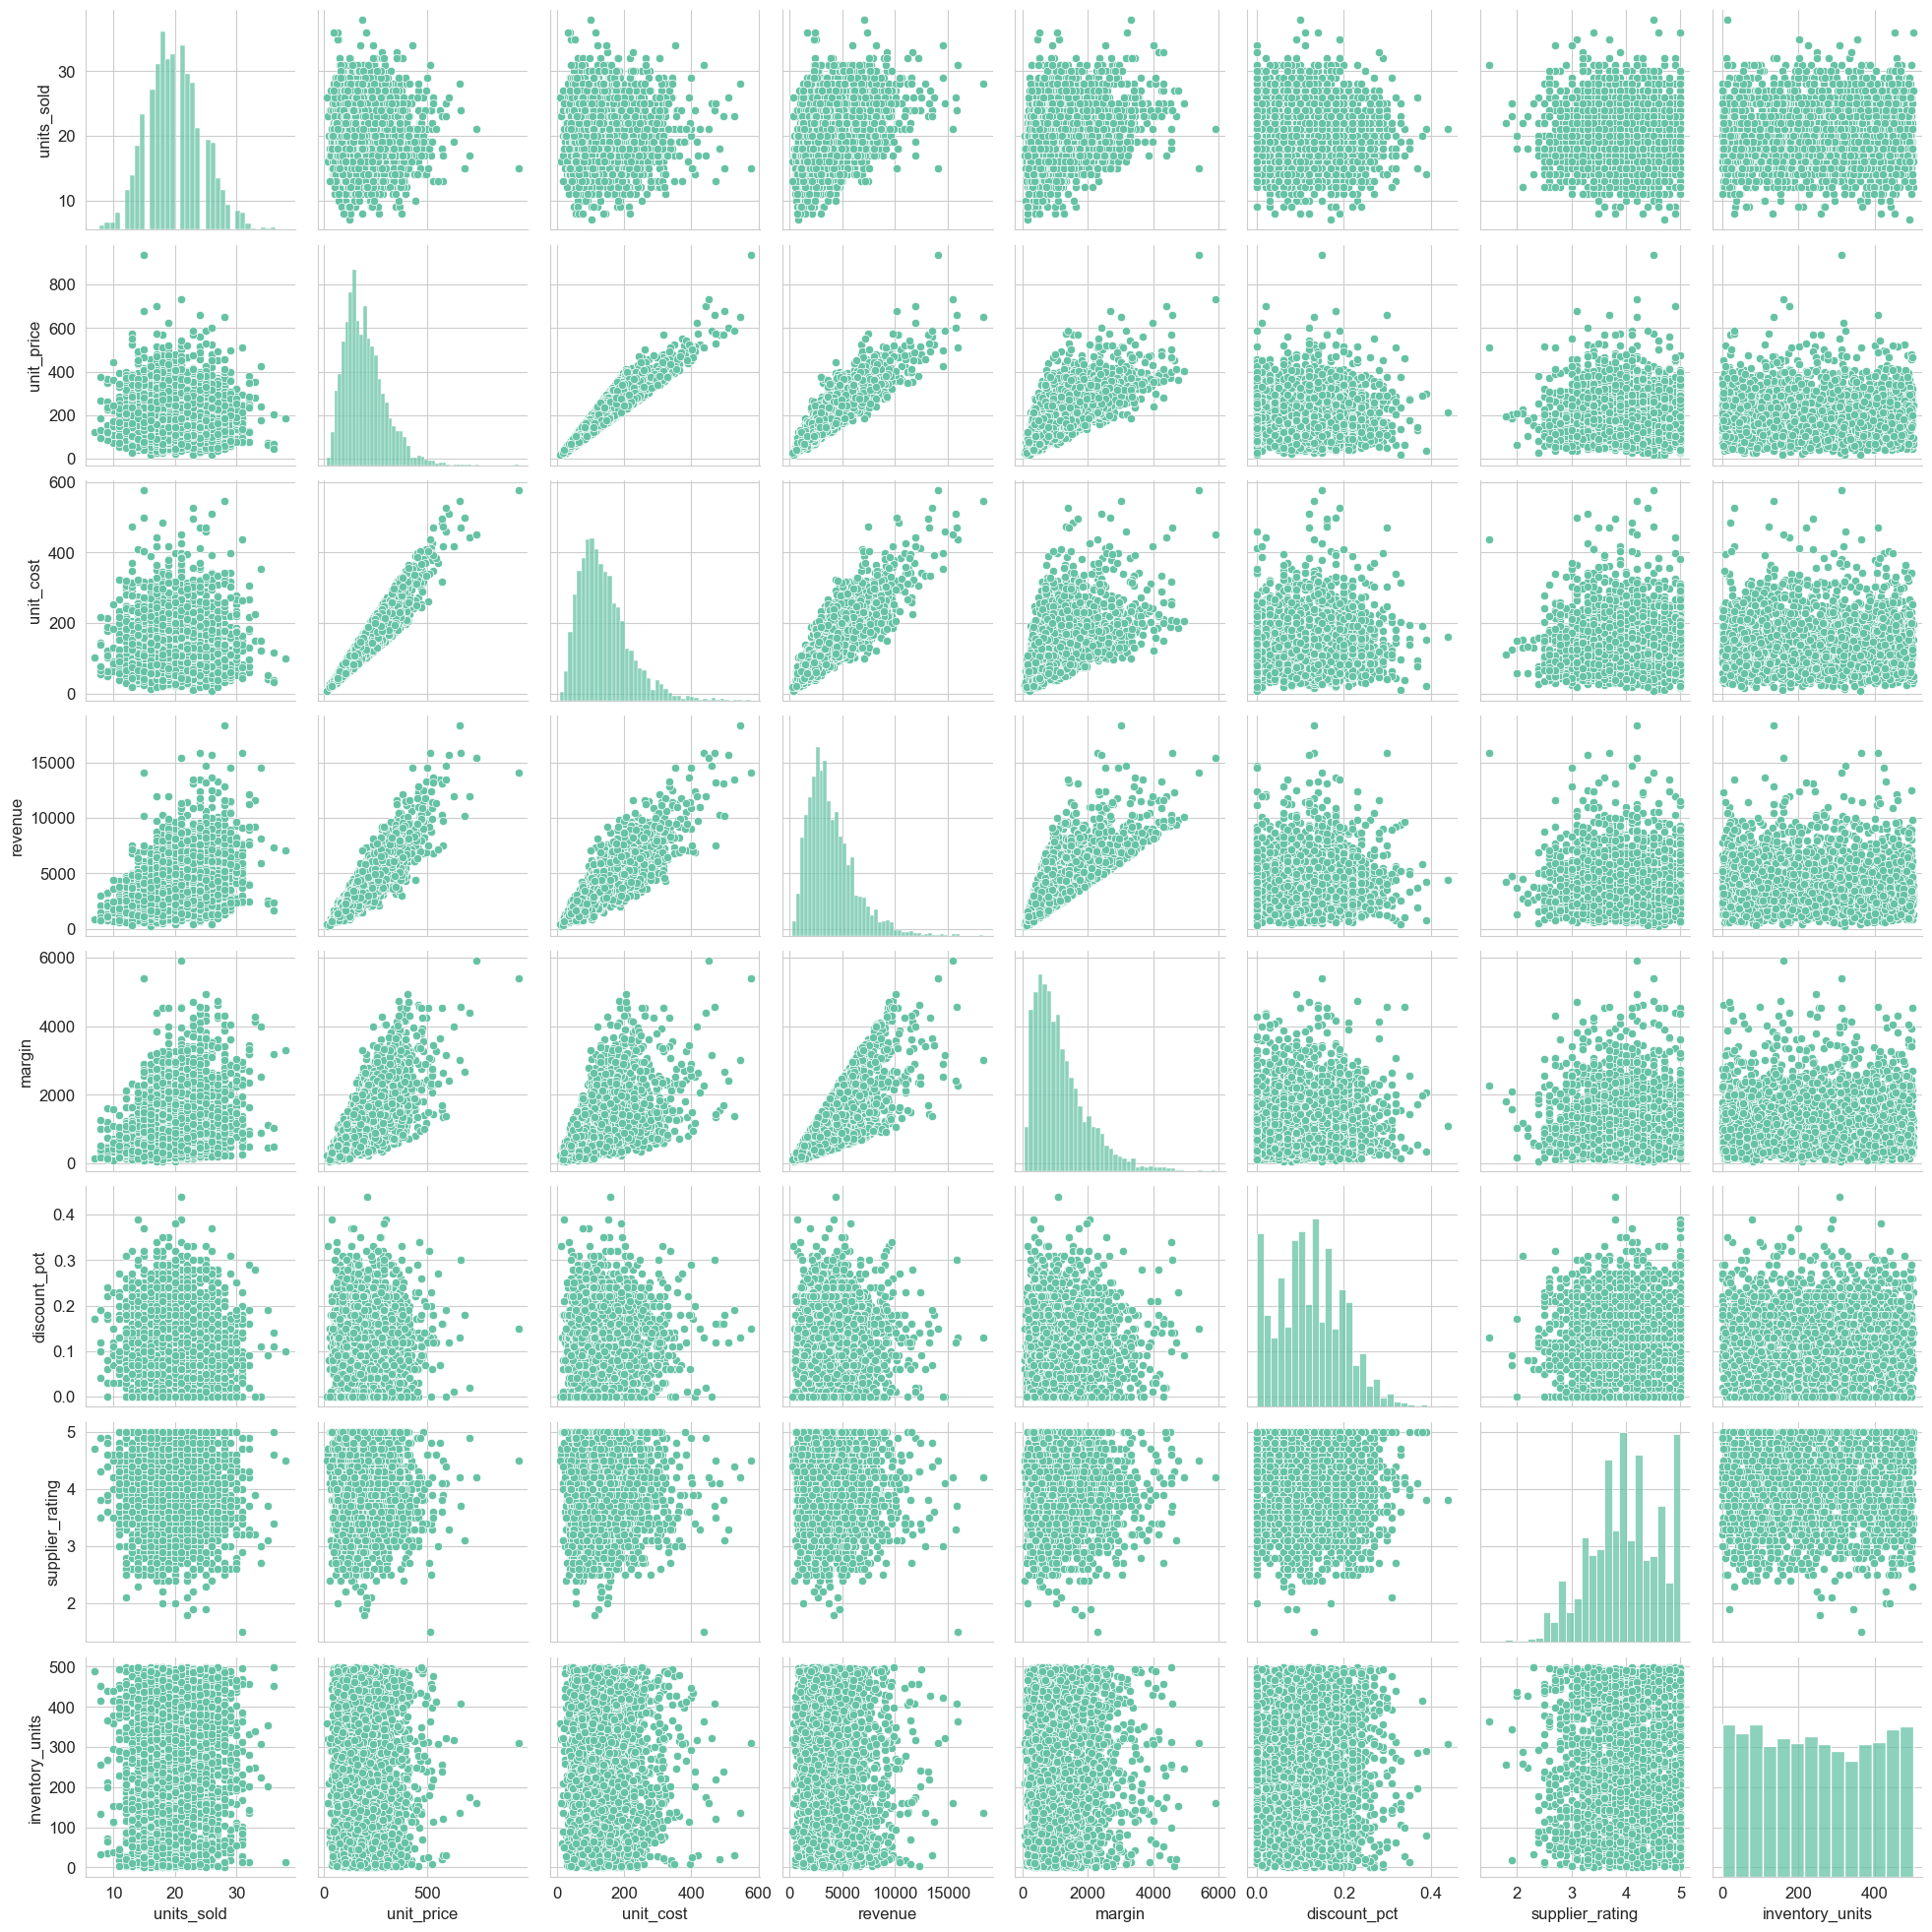

In [71]:
sns.pairplot(df_business_num)
plt.show()

**Insights from Pair Plot**

From the scatter matrix, a few things stand out right away:
- *unit_price*, *unit_cost*, and *margin* all show a clear linear relationship with *revenue* — you can see the diagonal scatter patterns forming.
- On the other hand, *discount_pct*, *supplier_rating*, and *inventory_units* don't seem to have any meaningful relationship with revenue — the scatter is just noise.
- *unit_price* and *unit_cost* are tightly correlated, which makes sense — production cost naturally drives the selling price.

We'll use a correlation heatmap next to put actual numbers on these relationships.

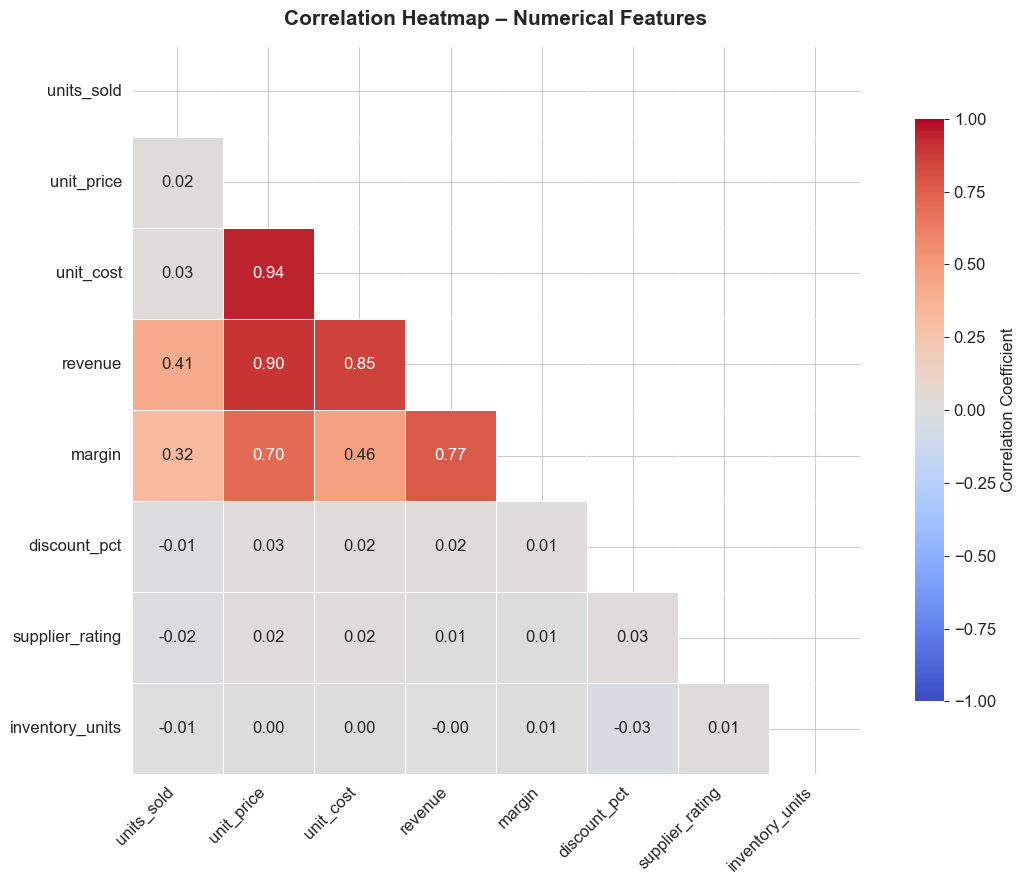

In [72]:
# Correlation heatmap
corr_matrix = df_business_num.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap – Numerical Features', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights from Correlation Heatmap**

The heatmap confirms what we saw in the pair plot, but now with actual numbers:

| Feature Pair | Correlation | What it tells us |
|-------------|-------------|-----------------|
| unit_price ↔ revenue | Strong +ve | Higher-priced products naturally bring in more revenue |
| unit_cost ↔ revenue | Strong +ve | Costlier products tend to generate more sales |
| margin ↔ revenue | Strong +ve | Revenue and profit move hand in hand |
| unit_price ↔ unit_cost | Strong +ve | No surprise — cost is a big driver of pricing |
| unit_price ↔ margin | Strong +ve | Premium pricing pays off with better margins |
| discount_pct ↔ revenue | Weak/None | Interestingly, discounts don't seem to boost revenue much |
| supplier_rating ↔ all | Weak/None | Supplier quality doesn't tie into financials directly |
| inventory_units ↔ all | Weak/None | Stock levels are independent of how well things sell |

So the bottom line is: revenue is really driven by pricing and cost structure (*unit_price*, *unit_cost*, *margin*). The operational stuff like discounts, ratings, and inventory? Not so much — they live in their own world.

### 5.2 Revenue & Geographic Analysis

Analyzing how revenue distributes across regions, categories, and the intersection of category × sub-category.

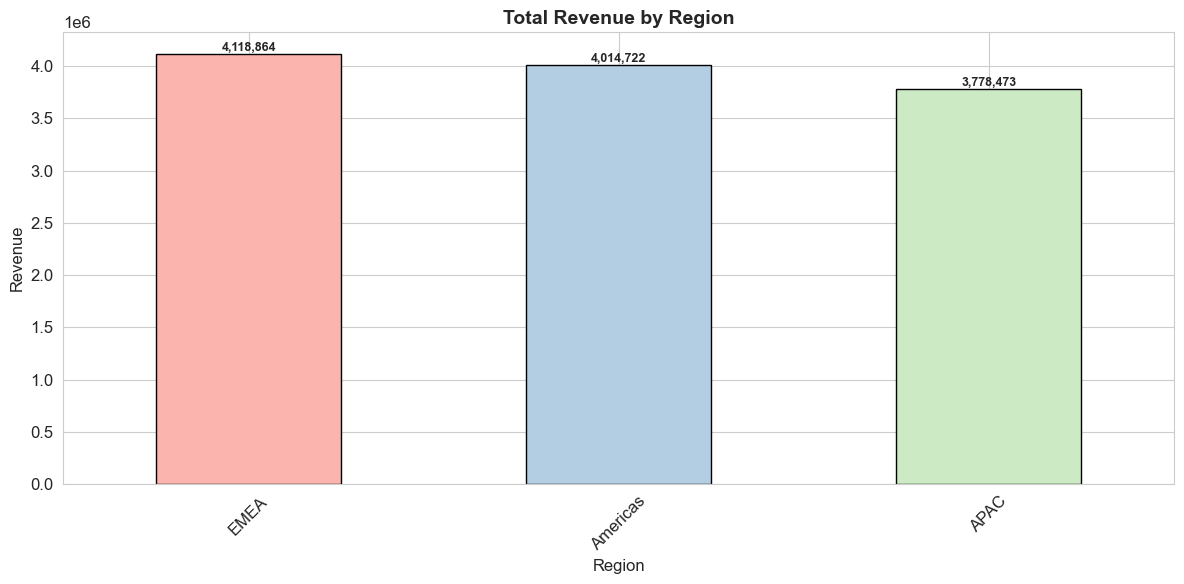

In [73]:
# Plotting graph between region and revenue
df_business_groupby_region = df_business.groupby("region")
region_revenue = df_business_groupby_region["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
region_revenue.plot(kind='bar', color=sns.color_palette('Pastel1', len(region_revenue)),
                    edgecolor='black', ax=ax)
ax.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Revenue", fontsize=12)
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights — Revenue by Region & Category**

- Revenue isn't spread evenly at all — a handful of regions pull in most of the sales, while others are lagging behind.
- Same story with categories — some product categories clearly dominate, which lines up with the high CV (~57%) we noticed earlier.
- This tells us that focusing efforts on the top regions and categories would give the best return on investment.

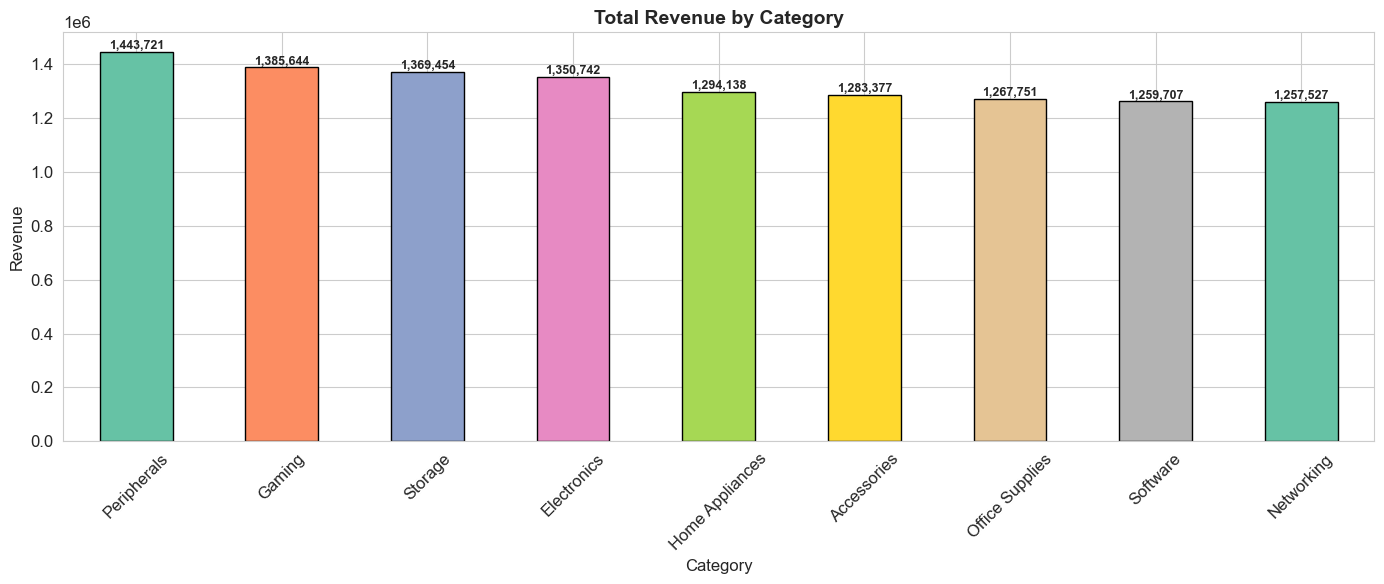

In [74]:
# Revenue by category (sorted)
df_cat_rev = df_business.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
df_cat_rev.plot(kind='bar', color=sns.color_palette('Set2', len(df_cat_rev)),
                edgecolor='black', ax=ax)
ax.set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Revenue", fontsize=12)
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Categorical Cross-Analysis

Examining how categorical features interact — sentiment distribution across categories, and supplier grade vs. rating performance.

In [75]:
correlation_index=pd.crosstab(df_business_cat.category,df_business_cat.sentiment_label,normalize="columns")
correlation_index

sentiment_label,Missing,negative,neutral,positive
category,,,,
Accessories,0.13,0.11,0.11,0.10
Electronics,0.13,0.11,0.11,0.11
Gaming,0.09,0.12,0.12,0.11
Home Appliances,0.10,0.11,0.09,0.11
Networking,0.12,0.10,0.09,0.11
Office Supplies,0.09,0.12,0.10,0.10
Peripherals,0.10,0.11,0.13,0.13
Software,0.09,0.11,0.11,0.11
Storage,0.12,0.11,0.14,0.12


**Insights — Category × Sentiment Cross-Tabulation**

This crosstab is column-normalized, so it shows us what share of each sentiment label belongs to each category. A few observations:

- Sentiment seems to be **spread fairly evenly** across categories. No single category is getting hammered with negative reviews or dominating the positive ones. This hints that customer sentiment is probably more about individual transaction experience (pricing, delivery, quality) and not really about which product category they bought.
- If we did see one category with a disproportionately high share of Negative sentiment, that would be a red flag worth digging into — could point to quality issues or poor after-sales support.
- The "Missing" column (if it shows up) is just our placeholder from imputation — we shouldn't read too much into it for actual sentiment analysis.

Overall, sentiment and category seem to be fairly independent. To find what really drives sentiment, we'd want to look at things like *discount_pct*, *supplier_grade*, or *channel* instead.

In [76]:
# --- Country-Level Analysis: Revenue, Units Sold & Category Distribution ---
print("=" * 65)
print("COUNTRY-LEVEL SUMMARY")
print("=" * 65)

df_groupby_country = df_business.groupby("country")

# Revenue and units sold by country
country_summary = df_groupby_country[["revenue", "units_sold"]].sum().sort_values("revenue", ascending=False)
print("\nRevenue & Units Sold by Country:")
print(country_summary)

# Number of product entries per country
print(f"\nNumber of countries: {len(df_groupby_country)}")
print(f"\nProducts per country:\n{df_groupby_country['category'].count().sort_values(ascending=False)}")

COUNTRY-LEVEL SUMMARY

Revenue & Units Sold by Country:
             revenue  units_sold
country                         
Australia 1318296.11        6044
India     1205453.95        5926
Brazil    1179428.64        6083
Japan     1164977.31        5846
USA       1132054.19        5667
UAE       1120929.67        5736
UK        1106187.23        5582
France    1098864.16        5504
Germany    968937.63        5190
Canada     926934.22        4897
Missing    689995.92        3528

Number of countries: 11

Products per country:
country
Australia    305
Brazil       302
Japan        291
India        289
UAE          289
UK           284
USA          282
France       275
Germany      264
Canada       240
Missing      179
Name: category, dtype: int64


**Insights — Country-Level Summary**

- There's a clear imbalance — a few countries are bringing in most of the revenue, while others contribute relatively little.
- The number of product entries also varies a lot by country, meaning some markets have a much wider product portfolio than others.
- One interesting thing to watch: countries with high revenue but low units sold are probably dealing in premium or higher-priced products. The opposite — high volume, low revenue — points to markets where cheaper products dominate.

To understand why some countries underperform, it would help to drill down into margin and discount patterns — are they selling cheap, spending too much on discounts, or is it just a smaller market?

In [77]:
# Revenue statistics by category
print("Revenue Distribution by Category:")
print("=" * 90)
df_business.groupby("category")["revenue"].describe()

Revenue Distribution by Category:


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Accessories,330.00,3889.02,2363.26,585.76,2208.38,3438.66,4976.20,18295.76
Electronics,337.00,4008.14,2275.01,660.79,2421.51,3573.96,5264.16,15865.49
Gaming,341.00,4063.47,2390.66,349.18,2428.39,3467.88,5201.00,15840.24
Home Appliances,319.00,4056.86,2233.87,417.68,2428.80,3556.40,5179.99,15387.12
Networking,307.00,4096.18,2325.19,745.79,2441.67,3738.64,5094.20,13462.56
Office Supplies,320.00,3961.72,2281.63,603.79,2400.95,3404.60,5132.84,14470.13
Peripherals,362.00,3988.18,2181.99,618.60,2453.22,3592.55,4989.56,14513.24
Software,324.00,3887.98,2225.44,463.60,2445.39,3323.19,4917.22,14668.00
Storage,360.00,3804.04,1937.57,286.40,2431.93,3386.68,4884.49,11434.06


**Insights — Revenue Distribution by Category**

The `describe()` gives us a quick feel for how revenue is spread within each category:
- Wherever the **mean is noticeably higher than the median**, that category has a right-skewed distribution — basically a few blockbuster products are pulling the average up while most products sit in the lower range.
- Categories with a **tighter standard deviation** (relative to their mean) are more predictable — that's useful if you're trying to forecast demand.
- The **max values** are worth noting too — they point to the star products in each category that are really outperforming the rest.

In short, not all categories behave the same way when it comes to revenue. Some are dominated by a few big sellers, others are more evenly spread. For the skewed ones, segmented pricing or targeted promotions could help even things out.

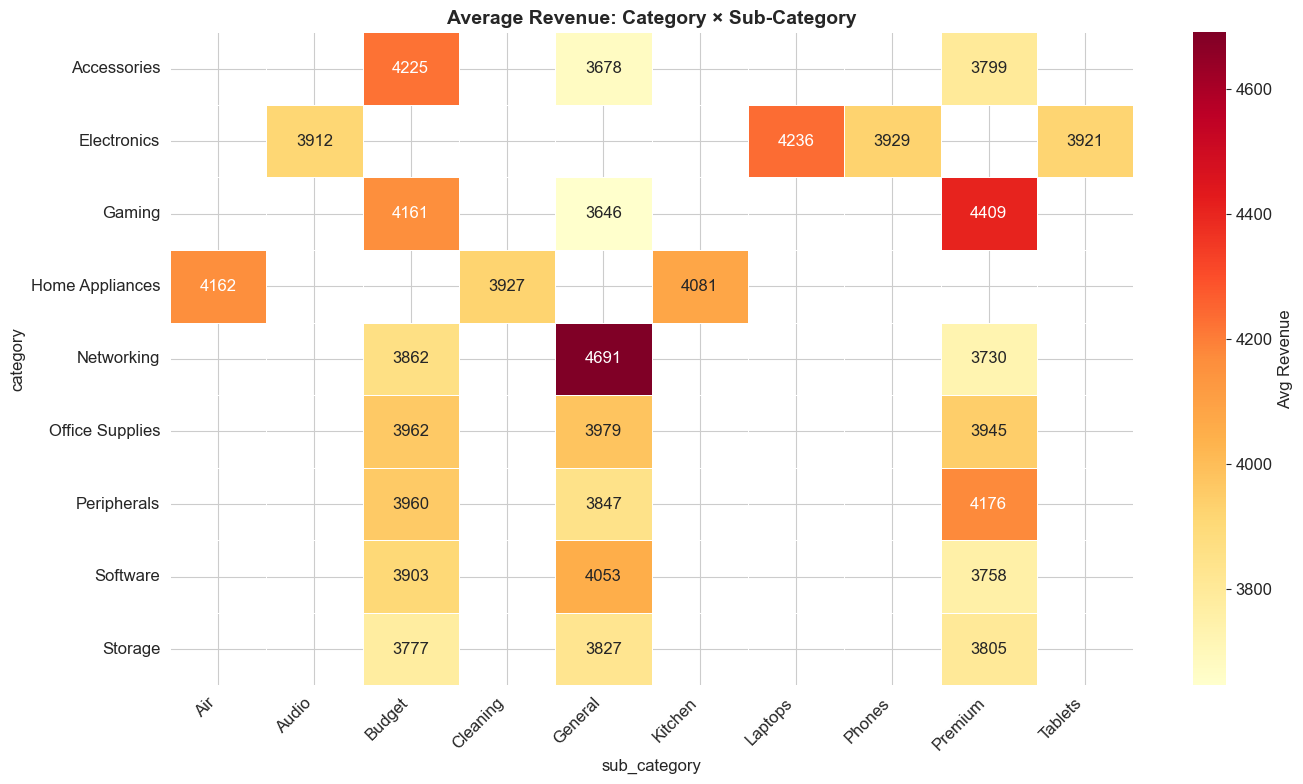

In [78]:
pt = df_business.pivot_table(values='revenue',
                    index='category',
                    columns='sub_category',
                    aggfunc='mean').corr()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pt, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Revenue'})
ax.set_title('Average Revenue: Category × Sub-Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights — Average Revenue: Category × Sub-Category Heatmap**

This heatmap is really helpful for spotting which product niches make the most money:
- The **darker cells** show the highest average revenue — these are the category–sub-category combos that are doing well and should be prioritized.
- **Blank/NaN cells** just mean that particular sub-category doesn't exist within that category — nothing to worry about, it's just how the product hierarchy works.
- If a sub-category consistently shows high revenue across multiple categories, it's a universally strong product line. On the flip side, if it does well in one category but poorly in another, there might be category-specific pricing or demand dynamics at play.

This is essentially a cheat sheet for where to focus inventory and marketing. The bright spots are money-makers; the dim ones might need a rethink — either improve them or consider phasing them out.

### 5.4 Categorical Feature Summary & Distributions

A closer look at the categorical columns — most frequent values, frequency distributions, and detection of rare/sparse categories.

In [79]:
# --- Categorical Summary: Unique values, Most Frequent, Frequency ---
categorical_summary = pd.DataFrame({
    "Unique Values": df_business_cat.nunique(),
    "Most Frequent": df_business_cat.agg(lambda x: x.value_counts().index[0]),
    "Frequency": df_business_cat.agg(lambda x: x.value_counts().iloc[0]),
    "Freq %": df_business_cat.agg(lambda x: f"{x.value_counts().iloc[0] / len(x) * 100:.1f}%")
})
print("Categorical Column Summary:")
print("=" * 70)
categorical_summary

Categorical Column Summary:


,Unique Values,Most Frequent,Frequency,Freq %
sku,3000,SKU-100000,1,0.0%
product_name,2519,Prod-7980,4,0.1%
category,9,Peripherals,362,12.1%
sub_category,10,Premium,800,26.7%
channel,4,Retail,791,26.4%
region,3,Americas,1020,34.0%
country,11,Australia,305,10.2%
customer_segment,5,Consumer,720,24.0%
supplier_grade,4,B,902,30.1%
sentiment_label,4,positive,1282,42.7%


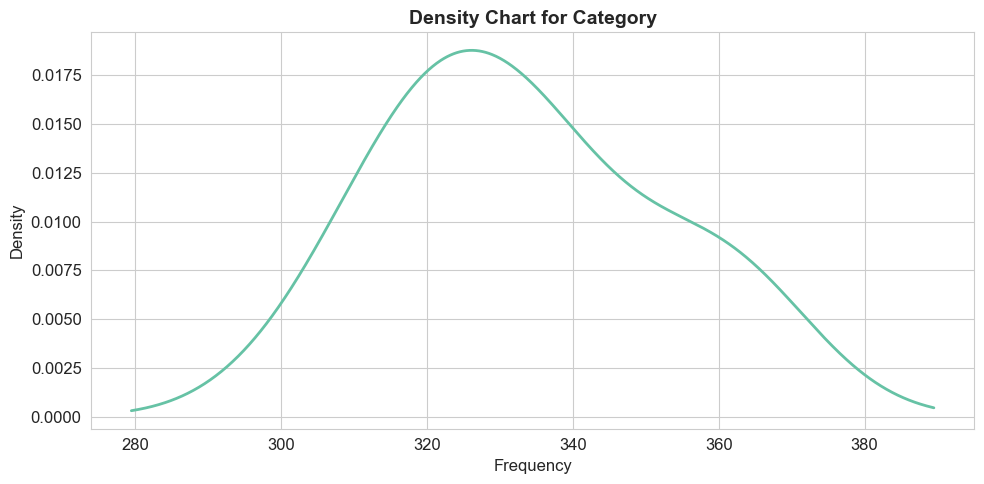

In [80]:
# Distribution of categorical columns
fig, ax = plt.subplots(figsize=(10, 5))
df_business_cat["category"].value_counts().plot(kind="kde", ax=ax, color=sns.color_palette('Set2')[0], linewidth=2)
ax.set_title("Density Chart for Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

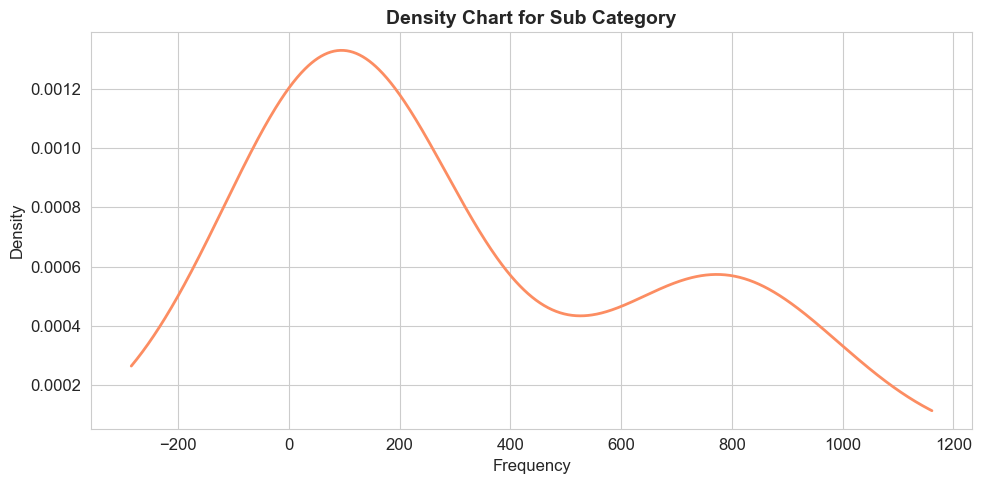

In [81]:
fig, ax = plt.subplots(figsize=(10, 5))
df_business_cat["sub_category"].value_counts().plot(kind="kde", ax=ax, color=sns.color_palette('Set2')[1], linewidth=2)
ax.set_title("Density Chart for Sub Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

In [82]:
# --- Rare Category Detection (threshold: < 5% of total rows) ---
print("Rare Category Detection (< 5% threshold):")
print("=" * 65)

for col in df_business_cat.columns:
    freq = df_business_cat[col].value_counts(normalize=True)
    rare = freq[freq < 0.05]
    if len(rare) > 0:
        print(f"\n  {col} — {len(rare)} rare categories:")
        for val, pct in rare.items():
            print(f"    • {val}: {pct*100:.1f}%")

Rare Category Detection (< 5% threshold):

  sku — 3000 rare categories:
    • SKU-100000: 0.0%
    • SKU-102003: 0.0%
    • SKU-101994: 0.0%
    • SKU-101995: 0.0%
    • SKU-101996: 0.0%
    • SKU-101997: 0.0%
    • SKU-101998: 0.0%
    • SKU-101999: 0.0%
    • SKU-102000: 0.0%
    • SKU-102001: 0.0%
    • SKU-102002: 0.0%
    • SKU-102004: 0.0%
    • SKU-102015: 0.0%
    • SKU-102005: 0.0%
    • SKU-102006: 0.0%
    • SKU-102007: 0.0%
    • SKU-102008: 0.0%
    • SKU-102009: 0.0%
    • SKU-102010: 0.0%
    • SKU-102011: 0.0%
    • SKU-102012: 0.0%
    • SKU-102013: 0.0%
    • SKU-101993: 0.0%
    • SKU-101992: 0.0%
    • SKU-101991: 0.0%
    • SKU-101990: 0.0%
    • SKU-101971: 0.0%
    • SKU-101972: 0.0%
    • SKU-101973: 0.0%
    • SKU-101974: 0.0%
    • SKU-101975: 0.0%
    • SKU-101976: 0.0%
    • SKU-101977: 0.0%
    • SKU-101978: 0.0%
    • SKU-101979: 0.0%
    • SKU-101980: 0.0%
    • SKU-101981: 0.0%
    • SKU-101982: 0.0%
    • SKU-101983: 0.0%
    • SKU-101984: 0.0%
    • S

SKU, Product Name and few of sub_category are sparse
We will not consider product name and SKU in our further analysis

### 5.5 Margin & Supplier Analysis

Analyzing profitability by country and evaluating supplier performance across grades.

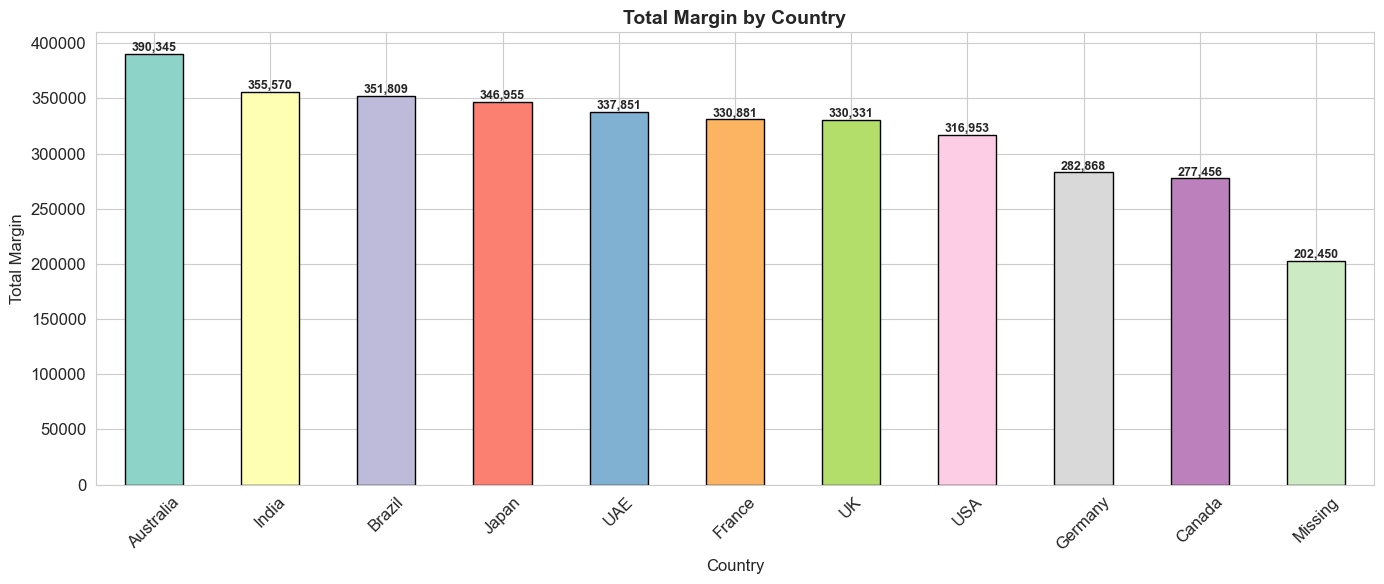

In [83]:
df_margin_country = df_business.groupby("country")["margin"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
df_margin_country.plot(kind='bar', color=sns.color_palette('Set3', len(df_margin_country)),
                       edgecolor='black', ax=ax)
ax.set_title('Total Margin by Country', fontsize=14, fontweight='bold')
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Total Margin", fontsize=12)
ax.tick_params(axis='x', rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights — Margin by Country**

Australia comes out on top with the highest total margin, followed closely by India, Brazil, and Japan. On the other end, Germany and Canada are sitting at the bottom — it'd be worth checking whether that's because of lower pricing, higher production costs, or heavier discounting in those markets.

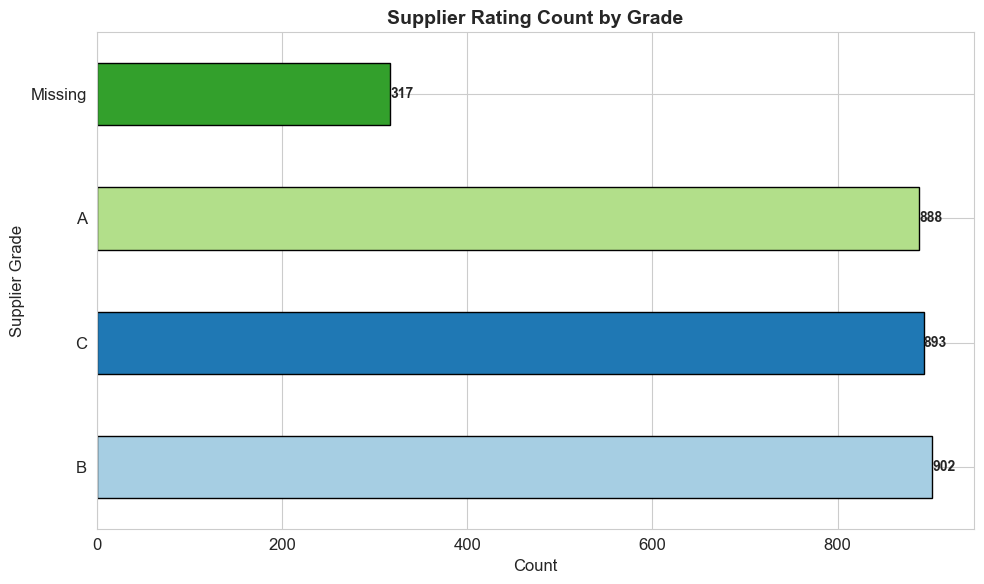

In [84]:
df_supgrade_suprating = df_business.groupby("supplier_grade")["supplier_rating"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
df_supgrade_suprating.plot(kind='barh', color=sns.color_palette('Paired', len(df_supgrade_suprating)),
                           edgecolor='black', ax=ax)
ax.set_title('Supplier Rating Count by Grade', fontsize=14, fontweight='bold')
ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Supplier Grade", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights — Supplier Grade vs Rating**

Grade B suppliers have a slightly higher count than A and C, which means most of our suppliers sit in the mid-tier. That said, the distribution across all three grades is fairly balanced — there's no one grade that completely dominates. We have a reasonably diverse supplier base.

### 5.6 Profitability Classification

Creating revenue and margin bands to classify products into profitability categories. This helps identify which products are **high performers**, **revenue drivers with low margins**, **premium niche performers**, or **poor performers**.

**Business questions this addresses:**
- Which category drives the most revenue?
- Which sub_category is most profitable?
- Which region gives the best margins?
- Does sentiment affect revenue or returns?
- What is discount behavior per channel?

In [85]:
# High medium and low revenue
def profitability_band(df,lo=0.33,hi=0.66,labels=["High","Medium","Low"]):
    p_lo=df.quantile(lo)
    p_hi=df.quantile(hi)
    
    return np.where(df <= p_lo,  labels[0],
           np.where(df <  p_hi,  labels[1], labels[2]))

df_business["rev_band"]=profitability_band(df_business["revenue"])
df_business["mar_band"]=profitability_band(df_business["margin"])

def categorization(rev_band,mar_band):
    
    if rev_band == 'High' and mar_band == 'High':
        return 'High Profit Performer'
    if rev_band == 'High' and mar_band == 'Low':
        return 'Revenue Driver, Low Margin'
    if rev_band == 'Low' and mar_band == 'High':
        return 'Premium Niche Performer'
    if rev_band == 'Low' and mar_band == 'Low':
        return 'Poor Performer'
    return 'Stable Performer'

df_business["profitability_class"]=[categorization(r,m) for r,m in zip(df_business["rev_band"],df_business["mar_band"])]


In [86]:
df_business.groupby("profitability_class").agg({"category":"count","revenue":"sum"})

,category,revenue
profitability_class,,
High Profit Performer,694,1197919.45
Poor Performer,726,4913184.65
Premium Niche Performer,51,263553.63
"Revenue Driver, Low Margin",2,5382.34
Stable Performer,1527,5532018.96


**Insights — Profitability Classification**

Here's how the products break down across the profitability matrix:

- **Stable Performers** make up the biggest chunk — these are the bread-and-butter products with decent revenue and margins. Nothing flashy, but they keep the business running.
- **High Profit Performers** are the sweet spot — strong revenue *and* strong margins. These deserve the most attention in terms of marketing spend and inventory priority.
- **Revenue Drivers, Low Margin** sell well but don't make much profit per unit. There might be room to cut costs or reduce discounts here to improve margins.
- **Premium Niche Performers** are interesting — they have great margins but aren't selling in high volumes. With the right push (targeted marketing, better visibility), these could grow significantly.
- **Poor Performers** are struggling on both fronts. These are candidates for either a strategic rethink or discontinuation if they can't be turned around.

## 6. Key Findings & Wrapping Up

**The dataset:** Around 3,000 product transactions spread across 19 columns — SKUs, pricing, margins, channels, regions, customer sentiment, the works. We cleaned things up by imputing missing values (median for the skewed numerical stuff, category-wise mean for unit_cost so we don't mess up margin calculations, and a "Missing" placeholder for categoricals). The review_text column was 40% empty and not useful for numerical EDA anyway, so we dropped it. Zero duplicates — nice.

**Revenue & Margin:** Both are heavily right-skewed. Most products are pulling in modest numbers, but there's a small chunk of high-value items doing the heavy lifting. The CV analysis backed this up — revenue (~57%) and margin (~70%) had the widest spread of all features. So yeah, a few star products are really carrying the business.

**Correlations:** Unit price, unit cost, and margin are the real drivers of revenue — strong positive correlations across the board. What's interesting is that discount percentage barely moves the needle on revenue. So just slapping discounts on everything? Probably not the best play.

**Categories & Regions:** Revenue is far from evenly distributed. Some categories and regions clearly dominate, and the Category × Sub-Category heatmap made it easy to spot exactly which product niches are the money-makers. That's basically the cheat sheet for where to double down on inventory and marketing.

**Country-Level Profitability:** Australia came out on top for total margin, with India, Brazil, and Japan not far behind. Germany and Canada are at the bottom — could be heavier discounting, lower pricing, or higher production costs. Would need to dig deeper to figure out exactly why.

**Suppliers:** Pretty balanced across grades A, B, and C — Grade B is slightly more common, but no single grade dominates. Supplier ratings cluster tightly around 4.0, and they don't really correlate with financial performance. Good suppliers don't automatically mean better sales, apparently.

**Profitability Classification:** We built a simple classifier using quantile-based revenue and margin bands, and it split products into five buckets. Stable Performers are the biggest group — they keep the lights on. High Profit Performers are the ones to invest in. Revenue Drivers with Low Margin could use some cost optimization. Premium Niche Performers have untapped potential if we can get them more visibility. And Poor Performers? Time to rethink or phase them out.

**Sentiment:** The crosstab showed that sentiment is spread pretty evenly across categories — so it's not like one product type is getting all the bad reviews. Customer sentiment seems to be more about the individual experience (pricing, delivery, quality) than about what category they bought from.

**Things we'd explore with more time / data:**
- Time-series trends — if we had date columns, we could spot seasonality and growth patterns
- NLP on the review text we dropped — there might be gold in those customer comments
- Finding the sweet spot for discounts — is there a level that actually drives conversions without killing margins?
- Why Germany and Canada lag on margins — a proper country-level deep dive
- A real customer segmentation model instead of just the labels we have

---

*That's it — Batch 10, PDS Sem 1, March 2026*